In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hmean
import seaborn as sns

In [2]:
from general_functions import remove_small_clusters, clinical_enrichment, calculate_stability_metrics, add_normalised_metric, measure_robustness

# Second benchmarking: obtaining the best algorithm

In [3]:
bench1_2clusters = pd.read_csv('../results/cluster_analysis/benchmarking_files/firstbench_2clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_3clusters = pd.read_csv('../results/cluster_analysis/benchmarking_files/firstbench_3clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_4clusters = pd.read_csv('../results/cluster_analysis/benchmarking_files/firstbench_4clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_5clusters = pd.read_csv('../results/cluster_analysis/benchmarking_files/firstbench_5clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
frames = [bench1_2clusters, bench1_3clusters, bench1_4clusters, bench1_5clusters]
results1_file = pd.concat(frames)
results2_file = pd.read_csv('../results/cluster_analysis/benchmarking_files/secondbench.csv',
                            dtype={'view_combination': str},
                            converters={'y_pred': eval, 'y_pred_idx': eval,
                                        'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
clinical_data_file = pd.read_csv('../data/TCGA/omics_data/raw/cancer_data_PAAD_clinical_data.tsv', sep='\t', header=0)

In [4]:
view_combination = results2_file['view_combination'].iloc[0]
n_clusters = results2_file['n_clusters'].iloc[0]
results1_combination = results1_file[(results1_file['n_clusters'] == n_clusters) & (results1_file['view_combination'] == view_combination)]
results2_prov = pd.concat([results1_combination, results2_file])
results2_robustness = measure_robustness(results2_prov)
def substitute_ampmech(df):
    amputation_mechanisms = ['edm', 'pm', 'mnar', 'mcar']
    no_amputation_df = df[df['amputation_mechanism'] == 'No']
    new_rows_list = []
    for mechanism in amputation_mechanisms:
        temp_df = no_amputation_df.copy()
        temp_df['amputation_mechanism'] = mechanism
        new_rows_list.append(temp_df)
    new_amputation_rows = pd.concat(new_rows_list, ignore_index=True)
    df_no_no = df[df['amputation_mechanism'] != 'No']
    df_updated = pd.concat([df_no_no, new_amputation_rows], ignore_index=True)
    return df_updated
results2_df = substitute_ampmech(results2_robustness)

In [5]:
import warnings
warnings.filterwarnings("ignore")
valid_results2, outlier_results2, outlier_patients2 = remove_small_clusters(results2_df, 20, verbose=False)
results_clin2 = clinical_enrichment(valid_results2, clinical_data_file)
normalised_silhouette2 = add_normalised_metric(results_clin2, metric='silhouette', variable_to_normalise='missing_percentage', greater_is_better=True)
stability_metrics_results2 = calculate_stability_metrics(normalised_silhouette2, random_state=42, progress_bar=True)
stability_metrics_results2[['AMI', 'ARI']] = stability_metrics_results2[['AMI','ARI']].fillna(value=0)
stability_metrics_results2[['AMI', 'ARI']] = stability_metrics_results2[['AMI', 'ARI']].clip(lower=0)
normalised_ami2 = add_normalised_metric(stability_metrics_results2, metric='AMI', variable_to_normalise='missing_percentage', greater_is_better=True)
results2 = normalised_ami2.copy()
results2['combined_metric'] = results2[['normalised_silhouette', 'normalised_AMI']].apply(lambda x: hmean(x), axis=1)
results2 = results2.sort_values('combined_metric', ascending=False)
results2['amputation_mechanism'] = results2['amputation_mechanism'].str.replace('edm', 'um')
results2

100%|██████████| 1/1 [00:31<00:00, 31.16s/it]


,dataset,algorithm,missing_percentage,amputation_mechanism,view_combination,n_clusters,silhouette,vrc,db,dbcv,...,rsi,bhi,normalised_silhouette,pvalue_logrank,n_enriched_clinical,robustness,AMI,ARI,normalised_AMI,combined_metric
41,TCGA_PDAC_subset,IMSR,0,mcar,110000,2,0.709546,230.115775,0.459471,0.691953,...,0.386387,0.116236,0.955713,0.778121,0.0,1.000000,0.753845,0.818214,1.000000,0.977355
45,TCGA_PDAC_subset,IMSR,20,mcar,110000,2,0.709546,230.115775,0.459471,0.691953,...,0.386387,0.116236,0.955713,0.778121,0.0,1.000000,0.753845,0.818214,1.000000,0.977355
44,TCGA_PDAC_subset,IMSR,20,um,110000,2,0.709546,230.115775,0.459471,0.691953,...,0.386387,0.116236,0.955713,0.778121,0.0,1.000000,0.753845,0.818214,1.000000,0.977355
40,TCGA_PDAC_subset,IMSR,0,um,110000,2,0.709546,230.115775,0.459471,0.691953,...,0.386387,0.116236,0.955713,0.778121,0.0,1.000000,0.753845,0.818214,1.000000,0.977355
47,TCGA_PDAC_subset,IMSR,20,pm,110000,2,0.709546,230.115775,0.459471,0.691953,...,0.386387,0.116236,0.947620,0.778121,0.0,1.000000,0.753845,0.818214,1.000000,0.973106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,TCGA_PDAC_subset,SIMCADC,60,mnar,110000,2,0.310981,30.348475,1.447423,0.857162,...,-0.372388,17.861402,0.649406,0.481830,0.1,0.594366,0.017797,0.019590,0.048816,0.090806
175,TCGA_PDAC_subset,SIMCADC,60,pm,110000,2,0.310981,30.348475,1.447423,0.857162,...,-0.372388,17.861402,0.649406,0.481830,0.1,0.594366,0.017797,0.019590,0.048816,0.090806
172,TCGA_PDAC_subset,SIMCADC,60,um,110000,2,0.270594,24.237275,1.548413,0.871785,...,-0.408498,19.558995,0.721846,0.549457,0.0,0.547887,0.006625,0.007132,0.018173,0.035453
176,TCGA_PDAC_subset,SIMCADC,80,um,110000,2,0.325551,31.808024,1.342250,0.835265,...,-0.315282,17.999437,0.868451,0.507727,0.0,0.554930,0.000989,0.000345,0.002714,0.005410


### Pointplots

In [6]:
from matplotlib import rcParams
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

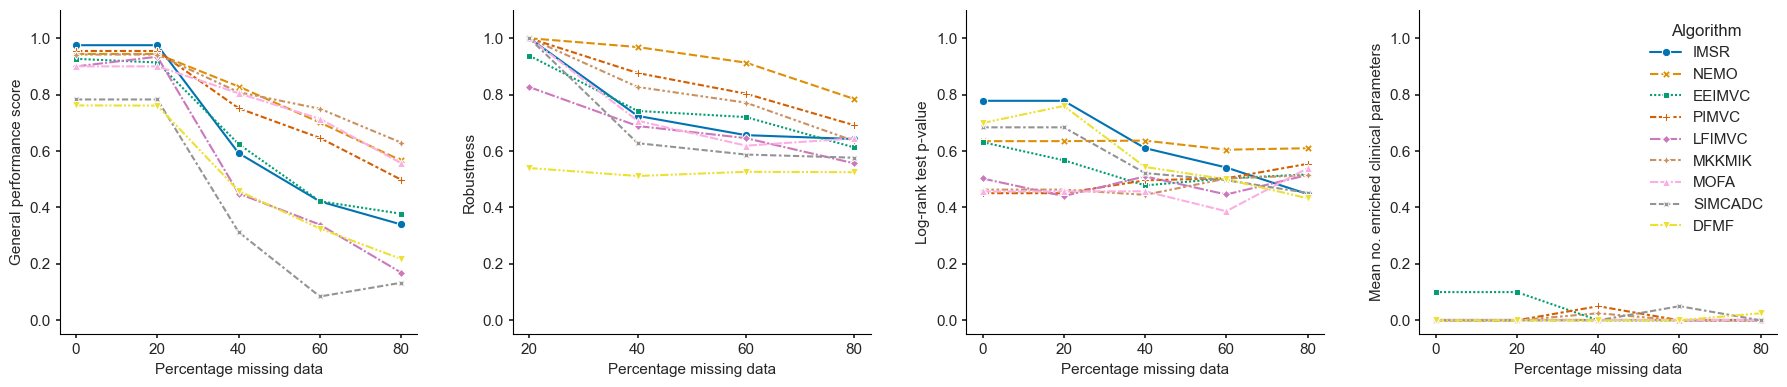

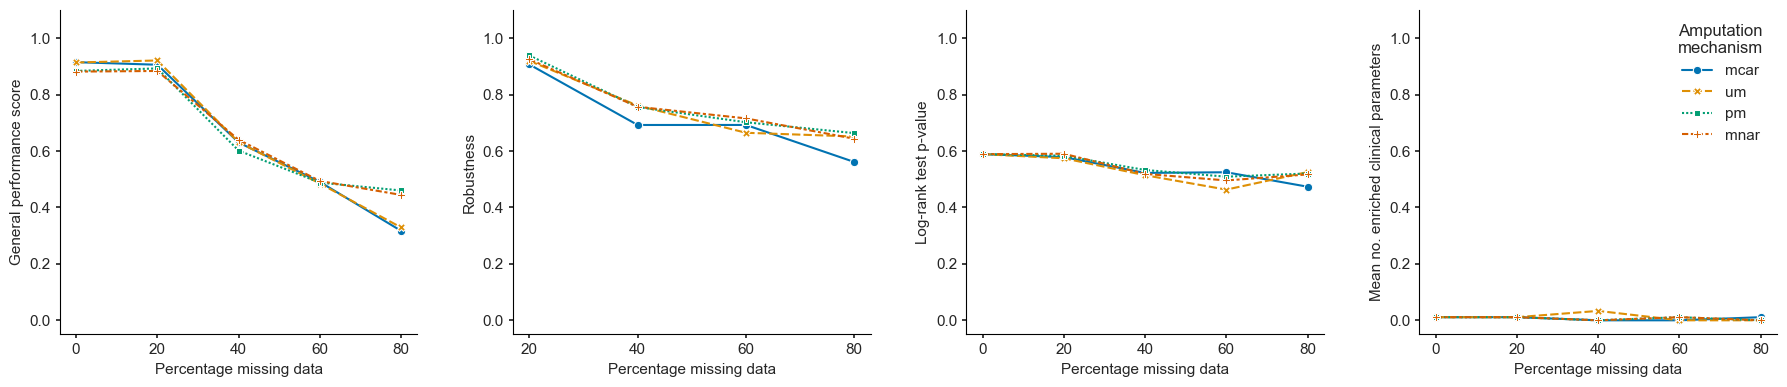

In [9]:
def plot_pointplots(df, colname_var, colname_metric, ax, ylabel):
    sns.lineplot(x='missing_percentage', y=colname_metric, data=df, hue=colname_var, style=colname_var,
                  palette="colorblind", ax=ax, markers=True, dashes=True, ci=None)
    ax.set_xlabel('Percentage missing data')
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=-0.05, top=(max(df[colname_metric])+0.05 if max(df[colname_metric])+0.05 > 1.1  else 1.1))
    plt.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(18,4))
# Pointplots by algorithm
plot_pointplots(results2, 'algorithm', 'combined_metric', ax[0], 'General performance score')
plot_pointplots(results2[results2['missing_percentage'] != 0], 'algorithm', 'robustness', ax[1], 'Robustness')
ax[1].set_xticks([20, 40, 60, 80])
plot_pointplots(results2, 'algorithm', 'pvalue_logrank', ax[2], 'Log-rank test p-value')
plot_pointplots(results2, 'algorithm', 'n_enriched_clinical', ax[3], 'Mean no. enriched clinical parameters')
handles_alg, labels_alg = ax[0].get_legend_handles_labels()
for i in ax.flat:
    i.legend().remove()
ax[3].legend(handles_alg, labels_alg, title="Algorithm", loc='upper right')
plt.tight_layout(w_pad=3)
#plt.savefig('FIGURES/benchmarking/algs.svg', bbox_inches='tight')
plt.show()

# Pointplots by amputation mechanism
fig, ax = plt.subplots(1, 4, figsize=(18,4))
plot_pointplots(results2, 'amputation_mechanism', 'combined_metric', ax[0], 'General performance score')
plot_pointplots(results2[results2['missing_percentage'] != 0], 'amputation_mechanism', 'robustness', ax[1], 'Robustness')
ax[1].set_xticks([20, 40, 60, 80])
plot_pointplots(results2, 'amputation_mechanism', 'pvalue_logrank', ax[2], 'Log-rank test p-value')
plot_pointplots(results2, 'amputation_mechanism', 'n_enriched_clinical', ax[3], 'Mean no. enriched clinical parameters')
handles_amp, labels_amp = ax[0].get_legend_handles_labels()
for i in ax.flat:
    i.legend().remove()
ax[3].legend(handles_amp, labels_amp, title="Amputation\nmechanism", loc='upper right')
plt.tight_layout(w_pad=3)
#plt.savefig('FIGURES/benchmarking/ampmech.svg', bbox_inches='tight')
plt.show()

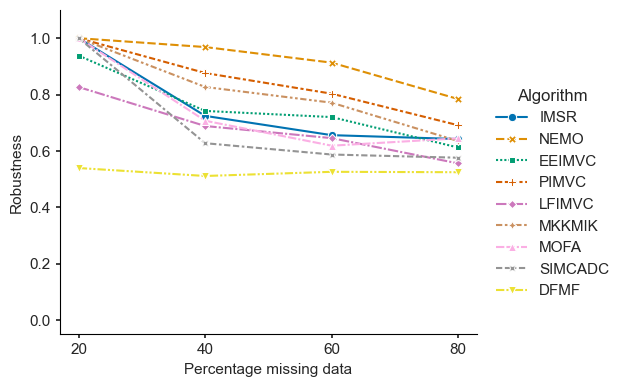

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_pointplots(results2[results2['missing_percentage'] != 0], 'algorithm', 'robustness', ax, 'Robustness')
ax.legend(title="Algorithm", bbox_to_anchor=(1.35, 0.8))
ax.set_xticks([20, 40, 60, 80])
#plt.savefig('FIGURES/benchmarking/best_alg.svg', bbox_inches='tight')
plt.show()

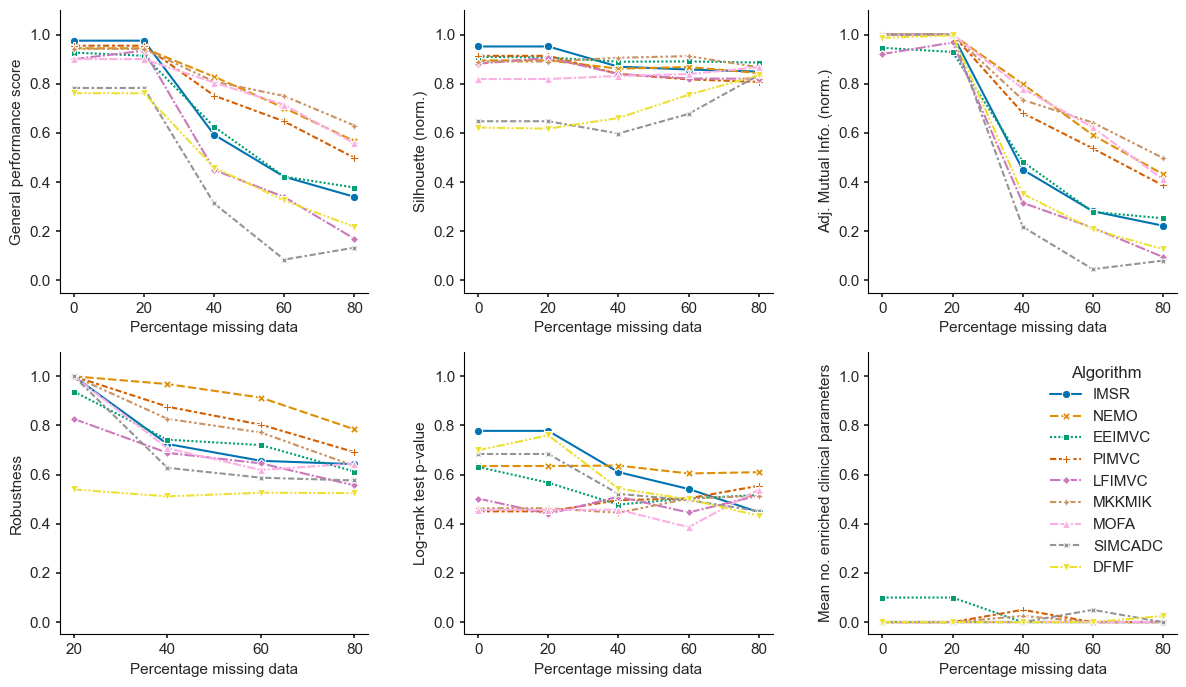

In [11]:
def plot_pointplots(df, colname_var, colname_metric, ax, ylabel):
    sns.lineplot(x='missing_percentage', y=colname_metric, data=df, hue=colname_var, style=colname_var,
                  palette="colorblind", ax=ax, markers=True, dashes=True, ci=None)
    ax.set_xlabel('Percentage missing data')
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=-0.05, top=(max(df[colname_metric])+0.05 if max(df[colname_metric])+0.05 > 1.1  else 1.1))
    plt.tight_layout()

fig, ax = plt.subplots(2, 3, figsize=(12,7))
# Pointplots by algorithm
plot_pointplots(results2, 'algorithm', 'combined_metric', ax[0, 0], 'General performance score')
plot_pointplots(results2, 'algorithm', 'normalised_silhouette', ax[0, 1], 'Silhouette (norm.)')
plot_pointplots(results2, 'algorithm', 'normalised_AMI', ax[0, 2], 'Adj. Mutual Info. (norm.)')
plot_pointplots(results2[results2['missing_percentage'] != 0], 'algorithm', 'robustness', ax[1, 0], 'Robustness')
ax[1, 0].set_xticks([20, 40, 60, 80])
plot_pointplots(results2, 'algorithm', 'pvalue_logrank', ax[1, 1], 'Log-rank test p-value')
plot_pointplots(results2, 'algorithm', 'n_enriched_clinical', ax[1, 2], 'Mean no. enriched clinical parameters')
handles_alg, labels_alg = ax[0, 0].get_legend_handles_labels()
for i in ax.flat:
    i.legend().remove()
ax[1, 2].legend(handles_alg, labels_alg, title="Algorithm", loc='upper right')
plt.tight_layout(w_pad=3)
#plt.savefig('FIGURES/benchmarking/algs_complete.svg', bbox_inches='tight')
plt.show()



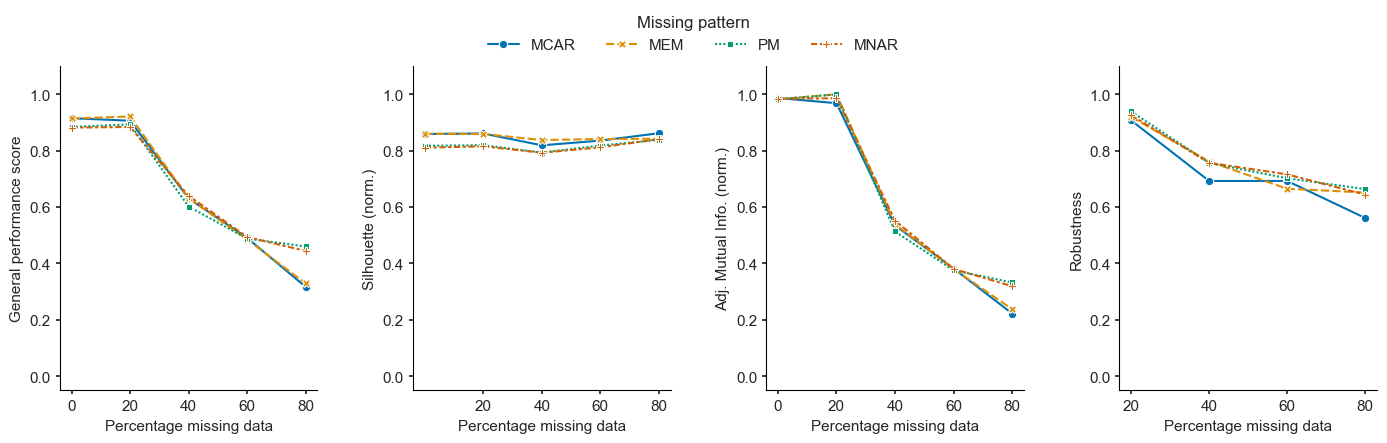

In [12]:
# Pointplots by amputation mechanism
fig, ax = plt.subplots(1, 4, figsize=(14,4))
plot_pointplots(results2, 'amputation_mechanism', 'combined_metric', ax[0], 'General performance score')
plot_pointplots(results2, 'amputation_mechanism', 'normalised_silhouette', ax[1], 'Silhouette (norm.)')
plot_pointplots(results2, 'amputation_mechanism', 'normalised_AMI', ax[2], 'Adj. Mutual Info. (norm.)')
plot_pointplots(results2[results2['missing_percentage'] != 0], 'amputation_mechanism', 'robustness', ax[3], 'Robustness')
ax[1].set_xticks([20, 40, 60, 80])
#plot_pointplots(results2, 'amputation_mechanism', 'pvalue_logrank', ax[1, 1], 'Log-rank test p-value')
#plot_pointplots(results2, 'amputation_mechanism', 'n_enriched_clinical', ax[1, 2], 'Mean no. enriched clinical parameters')

handles_amp, labels_amp = ax[0].get_legend_handles_labels()
# Update labels for missing pattern and convert to upper
labels_amp = [i.replace('um', 'mem').upper() for i in labels_amp]

for i in ax.flat:
    i.legend().remove()
# Create a single, horizontal legend at the top
fig.legend(
    handles_amp, labels_amp,
    title="Missing pattern",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),  # position above the plots
    ncol=len(labels_amp),        # number of columns = number of legend entries
    frameon=False
)
plt.tight_layout(w_pad=3)
#plt.savefig('../figures/ampmech_complete.svg', bbox_inches='tight')
plt.show()